In [1]:
import condor
import numpy as np

import scipy.fft as fft
import matplotlib.pyplot as plt

import os

import scipy
import scipy.interpolate as interpolate
import scipy.constants as constants

import h5py

from helper_functions import (electron_density_to_dn, write_text)

# Elementary constants
pi = constants.pi
e = constants.elementary_charge
h = constants.Planck
c = constants.speed_of_light

In [83]:
phot_eV = 9000 # beam energy in eV
phot_J = phot_eV * e # beam energy in J
phot_m = (h * c) / phot_J # beam wavelength in m
pulse_energy = 200e-6 # pulse energy in J
beam_pol = 'ignore' # beam polarization
beam_profile = 'gaussian' # beam profile

# Detector parameters
dsf = 4
pixel_size = dsf * 200e-6
dimY = 375 # for 6x it is 253 and for 4x it is 375
dimX = 375 # for 6x it is 253 and for 4x it is 375

#det_dist = 0.5
#det_dist = 0.48412423897154533 # old scaling (difference ~ )
#det_dist = 0.4831263056469039 # newer scaling (difference ~ )
det_dist = 0.48306051878575307 # newer scaling 2 (difference ~ )

cX, cY = dimX // 2, dimY // 2
pixel_num_x = dimX - dimX // 2
pixel_num_y = dimY - dimY // 2
D_particle = 15e-9 # GroEL size

# DENSS model
map3d, dx = condor.utils.emdio.read_map('denss/1ss8_denss.mrc')
map3d_scaled = electron_density_to_dn(map3d, phot_m)

# Beam diameter
focus_diam = 14e-9 # (14 nm by 14 nm)
focus_rad = focus_diam / 2
print(f'Beam diameter: {focus_diam * 1e6} um')

# Beam area 
beam_area = pi * (focus_rad ** 2)
print(f'Beam area: {beam_area * 1e12} um\u00b2') 

# Beam photon count 
beam_phots = pulse_energy / phot_J
print(f'Photon count: {beam_phots} photons')

# Beam fluence 
beam_fluence = beam_phots / beam_area
print(f'Beam fluence: {beam_fluence * 1e-12} ph/um\u00b2')
print(f'Beam fluence: {beam_fluence * phot_J * 1e-6} uJ/um\u00b2') 

# Edge resolution 
theta_pixel_x = 0.5 * np.arctan((pixel_num_x * pixel_size) / det_dist)
theta_pixel_y = 0.5 * np.arctan((pixel_num_y * pixel_size) / det_dist)

resolution_x = phot_m / (2.0 * np.sin(theta_pixel_x))
resolution_y = phot_m / (2.0 * np.sin(theta_pixel_y))
pix_real_x = 0.5 * resolution_x
pix_real_y = 0.5 * resolution_y

# Maximum corner resolution 
center_to_corner = np.sqrt((pixel_num_x * pixel_size) ** 2 + (pixel_num_x * pixel_size) ** 2)
theta_max = 0.5 * np.arctan(center_to_corner / det_dist)
resolution_max = phot_m / (2.0 * np.sin(theta_max)) 

oversampling = (det_dist * phot_m) / (pixel_size * D_particle)

shannon_groel = 1 / (D_particle * 1e9) 
shannon_diff = 1 / (dimX * pix_real_y * 1e9) 
print(f'Oversampling ratio: {oversampling}') 
print(f'Size of Shannon pixel GroEL: {shannon_groel} nm^-1')
print(f'The maximum corner resolution is: {resolution_max * 1e9} nm') 
print(f'The resolution along X-dimension is: {resolution_x * 1e9} nm') 
print(f'The resolution along Y-dimension is: {resolution_y * 1e9} nm') 
print(f'The pixel size in real space along X-dimension is: {pix_real_x * 1e9} nm') 
print(f'The pixel size in real space along Y-dimension is: {pix_real_y * 1e9} nm') 

# Source 
source = condor.Source(wavelength=phot_m, pulse_energy=pulse_energy, focus_diameter=focus_diam,
                       polarization=beam_pol, profile_model=beam_profile)

# Particle
part_map = condor.ParticleMap(geometry='custom', map3d=map3d_scaled,
                              rotation_formalism=None, dx=dx)

particle_set = {"particle_map" : part_map}

# Detector instance 
detector = condor.Detector(distance=det_dist, pixel_size=pixel_size, nx=dimX, ny=dimY, 
                           solid_angle_correction=False)

# Experiment 
condor_experiment = condor.Experiment(source, particle_set , detector)

# Getting q-map
q_map = condor_experiment.get_qmap(nx=dimX,ny=dimY,cx=None,cy=None,pixel_size=pixel_size,detector_distance=det_dist,wavelength=phot_m)

Beam diameter: 0.014 um
Beam area: 0.00015393804002589986 um²
Photon count: 138700201654.68362 photons
Beam fluence: 901013171476962.5 ph/um²
Beam fluence: 1299224.0252399622 uJ/um²
Oversampling ratio: 5.545543631146063
Size of Shannon pixel GroEL: 0.06666666666666668 nm^-1
The maximum corner resolution is: 0.33453007915532545 nm
The resolution along X-dimension is: 0.45814595085825294 nm
The resolution along Y-dimension is: 0.45814595085825294 nm
The pixel size in real space along X-dimension is: 0.22907297542912647 nm
The pixel size in real space along Y-dimension is: 0.22907297542912647 nm


In [ ]:
# Finding scaling between Condor and Dragonfly q-map
if False:
    qmax = np.sqrt((detector.get_q_max(phot_m, pos="edge")**2).sum())
    qn = max([dimX, dimY])
    qmap_3d = detector.generate_qmap_3d(phot_m, qn=qn, qmax=qmax)
    
    qmap_3d_x = qmap_3d[:,:,:,0].flatten()
    qmap_3d_y = qmap_3d[:,:,:,1].flatten()
    qmap_3d_z = qmap_3d[:,:,:,2].flatten()
    
    lambda_dragonfly = 1.3776022048133363 # in Å
    det_dist_dragonfly = 500 # in mm
    pix_size = 0.8 # in mm
    ewald_rad = det_dist_dragonfly / pix_size # no units
    
    qs_condor = qmap_3d[0,0,187,0] - qmap_3d[0,0,186,0] # Condor delta_q
    qs_dr = 1 / (625 * lambda_dragonfly * 1e-10) # Dragonfly delta_q
    
    qs_scaling = qs_condor / (qs_dr * (2*pi)) # ratio between Condor and Dragonfly q scaling

In [84]:
qmax = np.sqrt((detector.get_q_max(phot_m, pos="edge")**2).sum())
qn = max([dimX, dimY])
qmap_3d = detector.generate_qmap_3d(phot_m, qn=qn, qmax=qmax)

qmap_3d_x = qmap_3d[:,:,:,0].flatten()
qmap_3d_y = qmap_3d[:,:,:,1].flatten()
qmap_3d_z = qmap_3d[:,:,:,2].flatten()

In [85]:
qmap_3d[186,186,186]

array([-72974665.14539146, -72974665.14539146, -72974665.14539146])

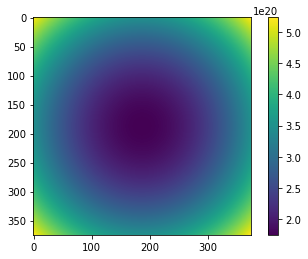

In [52]:
plt.imshow(np.sum(np.abs(qmap_3d[0,:,:,:])**2, axis=2))
plt.colorbar();

In [47]:
qmap_3d[0,0,187,0]

70658244.75663185

In [48]:
qmap_3d[0,0,187,1]

-13213091769.490068

In [49]:
qmap_3d[0,0,187,2]

-13213091769.490068

In [44]:
np.unravel_index(np.argmin(np.abs(qmap_3d)), shape=qmap_3d.shape)

(0, 0, 187, 0)

In [23]:
qmap_3d_x

array([-1.32130918e+10, -1.31424335e+10, -1.30717753e+10, ...,
        1.30717753e+10,  1.31424335e+10,  1.32130918e+10])

In [26]:
np.diff(qmap_3d_x)

array([70658244.75663185, 70658244.75663185, 70658244.75662994, ...,
       70658244.75662994, 70658244.75662994, 70658244.75662994])

In [24]:
qmap_3d_y

array([-1.32130918e+10, -1.32130918e+10, -1.32130918e+10, ...,
        1.32130918e+10,  1.32130918e+10,  1.32130918e+10])

In [32]:
np.diff(qmap_3d_y)

array([0., 0., 0., ..., 0., 0., 0.])

In [25]:
qmap_3d_z

array([-1.32130918e+10, -1.32130918e+10, -1.32130918e+10, ...,
        1.32130918e+10,  1.32130918e+10,  1.32130918e+10])

In [34]:
np.diff(qmap_3d_z)

array([0., 0., 0., ..., 0., 0., 0.])

In [86]:
qs_condor = qmap_3d[0,0,187,0] - qmap_3d[0,0,186,0] # Condor delta_q

72974665.14539146

In [91]:
ewald_rad = det_dist_dragonfly / pix_size # no units
ewald_rad

625.0

In [95]:
lambda_dragonfly = 1.3776022048133363 # in Å
ewald_rad = det_dist_dragonfly / pix_size # no units
qs_dr = 1 / (625 * lambda_dragonfly * 1e-10) # Dragonfly delta_q

qs_scaling = qs_condor / (qs_dr * (2*pi)) # ratio between Condor and Dragonfly q scaling
qs_scaling

0.9999909946645001

In [71]:
# Simulating 3D Fourier volume of GroEL
write_text('3D propagation started!\n')
res3d = condor_experiment.propagate3d()
write_text('3D propagation finished!\n')

3D propagation started!
3D propagation finished!


In [88]:
# Casting Condor results to float64
def_rng = np.random.default_rng()
intensity3d = res3d['entry_1']['data_1']['data'].astype(np.float64)
amplitude3d = np.abs(res3d['entry_1']['data_1']['data_fourier']).astype(np.float64)
#intensity3d = intensity3d[:-1,:-1,:-1]
#amplitude3d = amplitude3d[:-1,:-1,:-1]

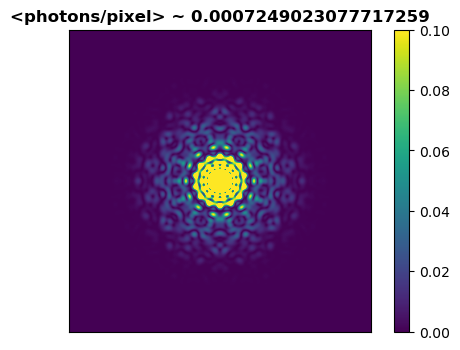

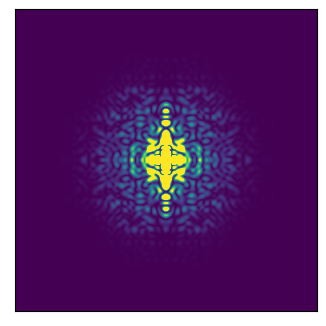

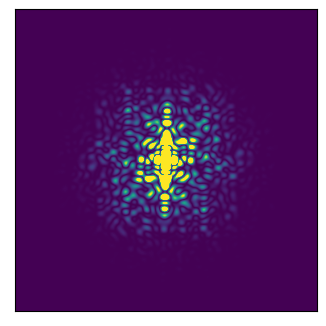

In [89]:
center = intensity3d.shape[0] // 2
scaling = 0.75
plt.figure(1, dpi=100)
plt.imshow(intensity3d[center,:,:]**scaling, vmin=0, vmax=0.1)
plt.title(f'<photons/pixel> ~ {intensity3d.mean(axis=(0,1,2))}', weight='bold')
plt.xticks([])
plt.yticks([])
plt.colorbar()

plt.figure(2, dpi=100)
plt.imshow(intensity3d[:,center,:]**scaling, vmin=0, vmax=0.1)
plt.xticks([])
plt.yticks([])

plt.figure(3, dpi=100)
plt.imshow(intensity3d[:,:,center]**scaling, vmin=0, vmax=0.1)
plt.xticks([])
plt.yticks([]);

In [ ]:
# Saving 3D Fourier volume with some experimental parameters to h5 file 
file_name = f'3d_groel_agipd_9_kev_denss_dsf_{dsf}x'
with h5py.File(f'{file_name}.h5','a') as f_ptr:
    f_ptr['/3Dparticle/intensity'] = intensity3d
    f_ptr['/3Dparticle/amplitude'] =  amplitude3d
    f_ptr['/3Dparticle/quat'] = res3d['particles']['particle_00']['extrinsic_quaternion']
    f_ptr['/exp/phot_eV'] = phot_eV
    f_ptr['/exp/pulse_energy'] = pulse_energy
    f_ptr['/exp/beam_phots'] = beam_phots
    f_ptr['/exp/pixel_size_m'] = pixel_size
    f_ptr['/exp/oversampling'] = oversampling
    f_ptr['/exp/det_dist_m'] = det_dist
    f_ptr['/exp/focus_diam_m'] = focus_diam
    f_ptr['/exp/polarization'] = beam_pol
    f_ptr['/exp/profile'] = beam_profile